# DS4DS Exercise Sheet 11

**General Instructions:**

- Review the weekly course material (lectures, readings, slides, etc.) before starting the exercises.
- Complete all assigned exercises independently before the Q&A session.
- Please use Julia Version 1.12.x to ensure compatibility.
- Please only write between the `#--- YOUR CODE STARTS HERE ---#` and `#--- YOUR CODE ENDS HERE ---#` comments.

#### **a)** Split your dataset into a training and evaluation dataset. The training dataset will be used to tune the parameters of your model and the evaluation data will be used to evaluate the generalization performance of your model. Use $u(t >= 37.5s)$ and $y(t >= 37.5s)$ for the training and $u(t < 37.5s)$ and $y(t < 37.5s)$ for the evaluation datasets. Additionally, provide the corresponding timesteps for the training and eval datasets, i.e., provide ```tsteps_training``` which contains all timesteps from the dataset with $t >= 37.5s$ and ```tsteps_eval``` which contains all timesteps with $t < 37.5s$.

### **Understanding the Problem**

The task requires you to perform a chronological train/test split on time-series data from a heating system.

Instead of randomly shuffling and splitting the data (which is common in standard machine learning but problematic for time-series), you need to divide the dataset at a specific point in time: $t = 37.5$.

* **Training Set:** Any data point recorded at or after $37.5$ seconds ($t \ge 37.5$). This data will be used to train or tune the parameters of your model.
* **Evaluation Set:** Any data point recorded before $37.5$ seconds ($t < 37.5$). This data will test how well your model generalizes to unseen data.

You must apply this condition to the time array (`tsteps`), the input voltage array (`u`), and the output temperature array (`y`), ensuring all three arrays remain perfectly aligned.

### **How it works:**

The expression `tsteps >= 37.5` generates an array of boolean values (`True` or `False`) of the exact same length as `tsteps`. When you pass this boolean "mask" back into the arrays as an index (e.g., `u[train_mask]`), NumPy efficiently extracts only the elements where the condition is `True`.

Implement the function below to split the dataset.

In [1]:
import numpy as np
import gzip

def loaddata_heating(normalize=True):
    # Open and read the gzipped file (rt = read text mode)
    with gzip.open("heating_system.dat.gz", "rt") as fh:
        data = np.loadtxt(fh)
    
    data_freq = 4
    
    # Subsample the data
    # Note: Python is 0-indexed. Julia's 1:data_freq:end translates to 0::data_freq
    data = data[0::data_freq, :]
    
    # Extract columns (Python 0-index vs Julia 1-index)
    t = data[:, 0] / 16.0  # time in seconds
    u = data[:, 1]         # input: voltage driving the lamp in volt
    y = data[:, 2]         # output: temperature measurement in °C
    
    dt = 2 * data_freq / 16.0  # time between samples in seconds
    
    # Convert to Float32 for performance
    t = t.astype(np.float32)
    u = u.astype(np.float32)
    y = y.astype(np.float32)
    
    if normalize:
        # Optional standardization of data (Z-Score Transform)
        # Using NumPy to subtract the mean and divide by standard deviation
        y = (y - np.mean(y)) / np.std(y)
        u = (u - np.mean(u)) / np.std(u)
        
    # t[0] is the first element, t[-1] is the last element
    tspan = (t[0], t[-1])
    
    return u, y, dt, tspan, t

# Example usage:
# u, y, dt, tspan, t = loaddata_heating(normalize=True)

In [2]:
import numpy as np
import torch
u, y, dt, tspan, tsteps = loaddata_heating(normalize = False)

def split_dataset(u, y, tsteps):
    """
    Creates a training and evaluation split based on a specific time threshold.
    
    Args:
        u (np.ndarray): System input data
        y (np.ndarray): System output data
        tsteps (np.ndarray): time steps of the data trajectories
        
    Returns:
        tuple: u_training, y_training, u_eval, y_eval, tsteps_training, tsteps_eval
    """
    
    # 1. Create boolean masks based on the time condition
    train_mask = tsteps >= 37.5
    eval_mask = tsteps < 37.5
    
    # 2. Apply the masks to filter the arrays for the training set
    u_training = u[train_mask]
    y_training = y[train_mask]
    tsteps_training = tsteps[train_mask]
    
    # 3. Apply the masks to filter the arrays for the evaluation set
    u_eval = u[eval_mask]
    y_eval = y[eval_mask]
    tsteps_eval = tsteps[eval_mask]
    
    return u_training, y_training, u_eval, y_eval, tsteps_training, tsteps_eval

# Example usage (assuming u, y, and tsteps are NumPy arrays):
u_training, y_training, u_eval, y_eval, tsteps_training, tsteps_eval = split_dataset(u, y, tsteps)
raw_initial_temperature = y_training[0]
# Convert it into a PyTorch tensor (1D tensor containing a single float)
x0 = torch.tensor([raw_initial_temperature], dtype=torch.float32)

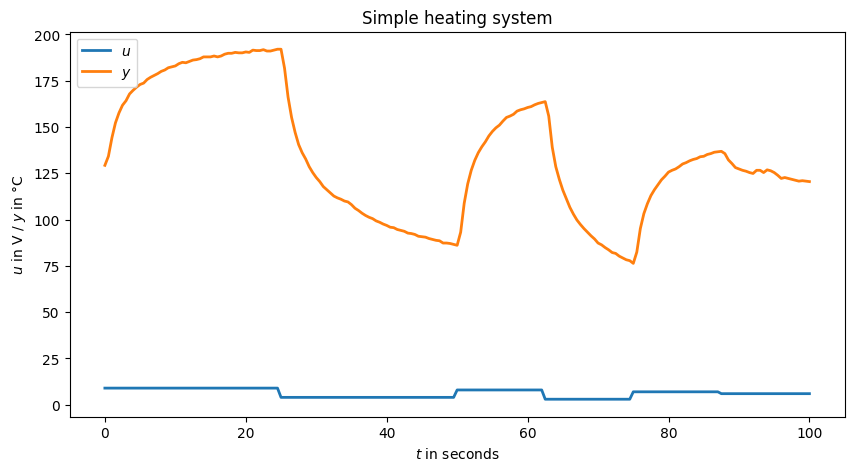

In [3]:
import matplotlib.pyplot as plt

# 1. Load the data (assuming the function from the previous step is defined)
u, y, dt, tspan, tsteps = loaddata_heating(normalize=False)

# 2. Initialize a figure (optional, but good practice for sizing)
plt.figure(figsize=(10, 5))

# 3. Plot the first line (equivalent to `plot(...)` in Julia)
plt.plot(tsteps, u, label=r"$u$", linewidth=2)

# 4. Plot the second line (equivalent to the mutating `plot!(...)` in Julia)
plt.plot(tsteps, y, label=r"$y$", linewidth=2)

# 5. Add labels, title, and legend
plt.title("Simple heating system")
plt.xlabel(r"$t$ in seconds")
plt.ylabel(r"$u$ in V / $y$ in °C")
plt.legend(loc="upper left")

# 6. Display the plot
plt.show()

#### **b)** Implement a function for the creation of a fully-connected feed-forward neural network in dependence of the layer sizes and the activation functions. Use ```Lux.jl``` to implement it in the function template given below.

In [4]:
import torch
import torch.nn as nn

def create_ann(layer_sizes, hidden_layer_activation_function, output_activation):
    """
    Creates a feed-forward neural network with the given parameters.
    
    Args:
        layer_sizes (list): List of layer sizes (e.g., [5, 32, 32, 2])
        hidden_layer_activation_function (nn.Module): Activation function for hidden layers
        output_activation (nn.Module): Activation function for the output layer
        
    Returns:
        nn.Sequential: Resulting fully-connected neural network
    """
    layers = []
    
    # Iterate through the layer sizes to create connections
    # We loop up to len - 1 because we need pairs: (input_size, output_size)
    for i in range(len(layer_sizes) - 1):
        in_features = layer_sizes[i]
        out_features = layer_sizes[i + 1]
        
        # 1. Add the fully connected (linear) layer
        layers.append(nn.Linear(in_features, out_features))
        
        # 2. Add the appropriate activation function
        if i < len(layer_sizes) - 2:
            # If it is a HIDDEN layer, apply the hidden activation
            if hidden_layer_activation_function is not None:
                layers.append(hidden_layer_activation_function)
        else:
            # If it is the OUTPUT layer (the final iteration), apply output activation
            if output_activation is not None:
                layers.append(output_activation)
                
    # Wrap the list of layers in a Sequential container
    # The * operator unpacks the list into separate arguments
    ann = nn.Sequential(*layers)
    
    return ann


### BEGIN SOLUTION (Setting the parameters as requested at the bottom of the image)
layer_sizes = [5, 32, 32, 2]
# Using ReLU for hidden layers (standard choice)
hidden_layer_activation_function = nn.ReLU() 
# No activation at the end is common for regression tasks (predicting continuous values)
output_activation = None 
### END SOLUTION

# Let's test it to see what the network looks like
model = create_ann(layer_sizes, hidden_layer_activation_function, output_activation)
print(model)

Sequential(
  (0): Linear(in_features=5, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)


In [5]:
# 1. Verify the overall output type
ann = create_ann(layer_sizes, hidden_layer_activation_function, output_activation)
assert isinstance(ann, nn.Sequential), "Network is not an nn.Sequential container"

### BEGIN TESTS
# 2. Create a test network: 
#    - [2, 40, 40, 1] architecture
#    - Tanh for hidden layers
#    - Identity (equivalent to x -> x, meaning no change) for output
test_ann = create_ann([2, 40, 40, 1], nn.Tanh(), nn.Identity())

# 3. Verify total layer count. 
#    In PyTorch, this is 6 blocks: 3 Linear layers + 2 hidden activations + 1 output activation
assert len(test_ann) == 6, "Network does not have the expected number of sequential blocks"

# 4. Verify Layer 1 dimensions and activation
assert test_ann[0].in_features == 2
assert test_ann[0].out_features == 40
assert isinstance(test_ann[1], nn.Tanh)

# 5. Verify Layer 2 dimensions and activation
assert test_ann[2].in_features == 40
assert test_ann[2].out_features == 40
assert isinstance(test_ann[3], nn.Tanh)

# 6. Verify Layer 3 (Output Layer) dimensions and activation
assert test_ann[4].in_features == 40
assert test_ann[4].out_features == 1
assert isinstance(test_ann[5], nn.Identity)

### END TESTS

#### **c)** In this subtask, we want to define the NODE of the form

$$
\begin{align}
    \frac{\mathrm{d}}{\mathrm{d}t} \hat{x}(t) &= \mathcal{M}_{\mathbf{w}} (\hat{x}(t), u(t)).
\end{align}
$$

To this end, we need to define the ODE in the function ```dxdt(x, w, t)``` and initialize the ```training_problem```.
Use ```create_ann``` from subtask **b)** to create a model for the ODE. If you were unable to properly implement it in **b)**, you are also allowed to create a model manually. However, you are restricted to fully-connected feed-forward neural networks. Use the variable ```w``` for the model parameters $\mathbf{w}$.

The layer sizes, activation functions and initialization are set here to help you with the following subtask.
If you want to design a different network, you are free to do so. Note, however that you might face a more complex optimization in that case.

### **Understanding the Problem**

We are tasked with building a **Neural Ordinary Differential Equation (NODE)**.

In a traditional physics-based model, you would write down an algebraic equation (like Newton's law of cooling) to define how the temperature changes over time. In a NODE, you replace that known physics equation with a Neural Network.

The equation:


$$\frac{d}{dt}\hat{x}(t) = \mathcal{M}_w(\hat{x}(t), u(t))$$

Here is what the components mean:

* **$\frac{d}{dt}\hat{x}(t)$:** The rate of change of the state (how fast the temperature is changing at time $t$).
* **$\hat{x}(t)$:** The current state (temperature) at time $t$.
* **$u(t)$:** The external input (voltage) driving the system at time $t$.
* **$\mathcal{M}_w$:** The neural network (parameterized by weights $w$) acting as the physics engine. It looks at the current temperature and voltage, and predicts the rate of change.

**The Role of the Interpolator (`s_interp`)**
Differential equation solvers do not just step neatly through your dataset; they evaluate the system at arbitrary microscopic time steps. However, you only recorded your voltage input $u$ at specific, discrete intervals. The `s_interp` function is a linear interpolator—it acts as a bridge, estimating the continuous value of $u(t)$ for any arbitrary microscopic time $t$ the ODE solver requests.

### **How it works:**

1. **Interpolation:** As the ODE solver moves forward in time, it passes the current time `t` to `dxdt`. We use the interpolator to find what the voltage `u_t` was at that exact moment.
2. **Concatenation:** We glue the current temperature `x` and the current voltage `u_t` together into a single array of size 2.
3. **Forward Pass:** We feed that array into the neural network `ann`. The network processes it and outputs a single value: the predicted derivative (how much the temperature is changing).

In [6]:
# theoretically you would need to interpolate separately for training and evaluation, but we will look past this here
# as the time is already dividing between the two
# Use a small, dependency-free linear interpolator to avoid compatibility issues
import numpy as np

# theoretically you would need to interpolate separately for training and evaluation, but we will look past this here
# as the time is already dividing between the two
# Use a small, dependency-free linear interpolator to avoid compatibility issues
def make_linear_interp(x, y):
    # This nested function acts as the closure
    def interp_fn(t):
        #handles out-of-bounds by clamping to the nearest endpoint
        if t <= x[0]:           
            return y[0]         
        elif t >= x[-1]:        
            return y[-1]        
        else:
            # np.searchsorted is the direct equivalent of searchsortedfirst
            i = np.searchsorted(x, t) # x- time array, t- time to find index for
            
            x0, x1 = x[i-1], x[i]
            y0, y1 = y[i-1], y[i]
            
            return y0 + (y1 - y0) * (t - x0) / (x1 - x0)
            
    return interp_fn

# capture local scalar interpolator for SISO
# (assuming tsteps and u are previously defined numpy arrays)
s_interp = make_linear_interp(tsteps, u) #not actually doing any interpolation yet - just arrays (inputs and time) are handed over to interp_fn
# this s_interp is used in the ODE function where we pass the target_time
# s_interp is developed using a method called closures, which retains the access to the dataset without needing to pass it every time we call the function. 
# This allows us to evaluate the input at any time point during the ODE integration without worrying about the underlying data structure.

# For this task, we have:
# - 1 state variable (the temperature)
# - 1 input variable (voltage)
# So total input size = 2
input_size = 2 
hidden_size = 16
output_size = 1

# Using nn.Tanh() for hidden layers and nn.Identity() (x -> x) for the output
ann = create_ann([input_size, hidden_size, output_size], nn.Tanh(), nn.Identity())

# Initialize parameter and state variables
seed = 2  # This seed gives a good initial state for optimization

# In PyTorch, weights are stored INSIDE the model, not as a separate array.
# To replicate Julia's MersenneTwister(seed), we just set the global PyTorch seed 
# before creating or resetting the network to ensure reproducible weight initialization.
torch.manual_seed(seed)


### BEGIN SOLUTION
# define dxdt using a safe input construction to avoid shape mismatches
def dxdt(t, x):
    """
    Evaluates the Neural ODE derivative.
    """
    # 1. Handle time 't'. ODE solvers might pass 't' as a tensor or a float.
    # .item() safely extracts the standard Python float from a 0D tensor.
    t_val = t.item() if isinstance(t, torch.Tensor) else t
    
    # Get the interpolated voltage at this exact time
    u_val = s_interp(t_val)
    
    # 2. SAFE INPUT CONSTRUCTION: 
    # ODE solvers can be unpredictable with the shape of 'x' (it might be a scalar, 
    # a 0D tensor, or a 1D tensor). We force both variables to be exactly 1D tensors 
    # of length 1 to guarantee torch.cat doesn't crash.
    if not isinstance(x, torch.Tensor):
        x = torch.tensor([x], dtype=torch.float32)
        
    x_safe = x.view(-1) # Ensures shape is [1]
    u_safe = torch.tensor([u_val], dtype=torch.float32)
    
    # 3. Concatenate the state (temperature) and input (voltage)
    nn_input = torch.cat([x_safe, u_safe], dim=0)
    
    # 4. Forward pass
    dx = ann(nn_input)
    
    return dx

### END SOLUTION

### 1. The "Closure" (Nested Function)

```python
def make_linear_interp(x, y):
    def interp_fn(t):
        ...
    return interp_fn

```

Instead of writing a function where you have to pass the massive `x` (time) and `y` (voltage) arrays every single time you want a single point, this structure "memorizes" the arrays. It returns a lightweight, custom function `interp_fn(t)` that only requires the specific time $t$ you are inquiring about.

### 2. Handling the Boundaries (Clamping)

```python
        if t <= x[0]:
            return y[0]
        elif t >= x[-1]:
            return y[-1]

```

If the ODE solver tries to look into the past (before your first data point) or into the future (after your last data point), the function prevents an out-of-bounds error. It simply "clamps" the value, returning a flat line extending outward from the first or last known voltage.

### 3. The Binary Search (Efficiency)

```python
        else:
            i = np.searchsorted(x, t)
            
            x0, x1 = x[i-1], x[i]
            y0, y1 = y[i-1], y[i]

```

If your target time $t$ is safely within the dataset, the code needs to find which two recorded timestamps it falls between.
Instead of checking every single point one by one (which is slow), `np.searchsorted` uses a highly efficient **binary search** algorithm to instantly locate the exact index `i`. It then grabs the exact time and voltage coordinates immediately before (`x0`, `y0`) and immediately after (`x1`, `y1`) your target time.

### 4. The Math (Point-Slope Interpolation)

```python
            return y0 + (y1 - y0) * (t - x0) / (x1 - x0)

```

Finally, it calculates the exact value using the standard mathematical formula for linear interpolation:

$$y(t) = y_0 + \frac{y_1 - y_0}{x_1 - x_0}(t - x_0)$$

* **$(y_1 - y_0) / (x_1 - x_0)$** calculates the slope (rate of change) between the two known points.
* **$(t - x_0)$** calculates exactly how far past the left point $x_0$ you currently are.
* Multiplying the slope by the distance and adding it to the starting height $y_0$ gives you the exact proportional voltage at time $t$.


#### 5. Why `input_size = 2`?

A standard state-space model or differential equation calculates the rate of change based on the current environment.
Mathematically, $\frac{dx}{dt} = f(x, u)$.
To replace $f$ with a neural network, the network needs to see both pieces of information simultaneously. Therefore, the input layer must have 2 neurons: one to receive the current temperature ($x$) and one to receive the current voltage ($u$).

#### 6. "Safe Input Construction" (Shape Mismatches)

Using a "safe input construction" is a very common requirement when mixing ODE solvers with neural networks.
As the ODE solver computes the integrals, it passes values to your `dxdt` function. Depending on the specific step of the mathematical solver (like Runge-Kutta), it might pass `x` as:

* A bare float: `25.3`
* A zero-dimensional tensor: `tensor(25.3)`
* A one-dimensional tensor: `tensor([25.3])`

If you attempt to concatenate a 0-dimensional tensor with a 1-dimensional tensor using `torch.cat`, the program will instantly crash. The "safe" construction forces everything into standard 1D arrays (`[val]`) before they ever touch the neural network.

#### **d)** Next, we want to implement the forward pass of the NODE.

Implement the function below that takes the parameters of the model $\mathbf{w}$, an ODE problem, the initial state $x_0$ and the timesteps and returns the state trajectory $\hat{\mathbf{x}}_n$.
Use the Tsit5 ODE solver, but non-adaptive.

In [7]:
import torch
# You will need to install torchdiffeq: pip install torchdiffeq
from torchdiffeq import odeint

def predict_NODE(w, problem, x0, tsteps, dt):
    """
    NODE forward pass.
    
    Args:
        w: Parameters of the model (Kept for signature compatibility, 
           but handled implicitly by PyTorch).
        problem: The ODE derivative function (e.g., our dxdt function).
        x0 (torch.Tensor): Initial state of the trajectory.
        tsteps (torch.Tensor): Time steps of the trajectory.
        dt (float): The time between two samples in the trajectory.
        
    Returns:
        torch.Tensor: Resulting state trajectory.
    """
    
    # 1. Ensure inputs are standard PyTorch tensors
    if not isinstance(x0, torch.Tensor):
        x0 = torch.tensor([x0], dtype=torch.float32)
    if not isinstance(tsteps, torch.Tensor):
        tsteps = torch.tensor(tsteps, dtype=torch.float32)
    
    # 2. Solve the ODE using torchdiffeq
    # We use 'rk4' (4th order Runge-Kutta) with a fixed step size to replicate
    # the behavior of a non-adaptive Tsit5 solver.
    trajectory = odeint(
        func=problem,             # The derivative function (dxdt)
        y0=x0,                    # The initial state
        t=tsteps,                 # The exact timestamps to save the output
        method='rk4',             # Standard fixed-step explicit solver
        options={'step_size': dt} # Forces the solver to be non-adaptive
    )
    
    return trajectory

# Example usage (assuming dxdt and other variables are defined from previous steps):
# x0_tensor = torch.tensor([y_training[0]], dtype=torch.float32)
# tsteps_tensor = torch.tensor(tsteps_training, dtype=torch.float32)
# trajectory = predict_NODE(None, dxdt, x0_tensor, tsteps_tensor, dt)

In [8]:
# Verify the function exists and is callable
assert callable(predict_NODE), "predict_NODE is not a function"

### BEGIN TESTS

test_x0 = torch.tensor([2.0], dtype=torch.float32)
test_w = torch.tensor([0.5], dtype=torch.float32)
test_dt = 0.1

test_tsteps = torch.linspace(0, 1, steps=10)

# PyTorch's odeint expects the derivative function to explicitly take (t, x)
# We capture test_w from the outer scope to mimic the w * x behavior
def dummy_ode(t, x):
    return test_w * x

# In Python, we do not need the ODEProblem wrapper. 
# We just pass the raw dummy_ode function directly as the 'problem'.
trajectory = predict_NODE(
    w=test_w, 
    problem=dummy_ode, 
    x0=test_x0, 
    tsteps=test_tsteps, 
    dt=test_dt
)

# odeint returns a tensor of shape [10, 1]. .squeeze() flattens it to [10] for easy reading/comparison
flattened_trajectory = trajectory.squeeze()
print("Given trajectory:\n", flattened_trajectory)

expected_trajectory = torch.tensor([
    2.0, 2.114255489520473, 2.2350381374837274, 2.362720825731292, 
    2.497697738003365, 2.640385576868242, 2.7912248501721817, 
    2.950681230981243, 3.119246995213576, 3.297442541400258
], dtype=torch.float32)

# torch.allclose is the PyTorch equivalent of Julia's isapprox
assert torch.allclose(flattened_trajectory, expected_trajectory, rtol=1e-3, atol=1e-3), "Trajectory does not match expected values"
print("Test passed successfully!")

### END TESTS

Given trajectory:
 tensor([2.0000, 2.1145, 2.2355, 2.3634, 2.4985, 2.6412, 2.7920, 2.9513, 3.1196,
        3.2974])
Test passed successfully!


#### **e)** Implement the MSE loss function to compare model predictions and true trajectory. Optimize the parameters $\mathbf{w}$ of your model given in subtask c) using the given optimizer. Design an adequate optimization problem for the given template.


In [9]:
import torch.nn.functional as F
import torch.optim as optim
import copy

maxiters_task1 = 2000

### BEGIN SOLUTION (Top Block - Defining the Loss Function)
def loss_NODE_task1():
    """
    Calculates the Mean Squared Error (MSE) between the predicted 
    NODE trajectory and the true training data.
    (Assumes x0_training, tsteps_training, and y_training are globally defined from subtask a)
    """
    # 1. Generate the predicted trajectory using the function from subtask d
    pred_trajectory = predict_NODE(None, dxdt, x0, tsteps_training, dt)
    
    # 2. Flatten the prediction to match the 1D shape of the true data
    pred_trajectory = pred_trajectory.squeeze()

    # -> THE FIX: Convert the NumPy array to a PyTorch FloatTensor <-
    # (If y_training is already a tensor, this safely does nothing or casts the type)
    y_true_tensor = torch.tensor(y_training, dtype=torch.float32)
    
    # 3. Calculate and return the MSE loss
    loss = F.mse_loss(pred_trajectory, y_true_tensor)
    return loss
### END SOLUTION


def train_task1(maxiters=maxiters_task1, lr=1e-3, patience=15, tol=1e-6):
    # In PyTorch, we define an optimizer that hooks directly into the network's parameters
    optimizer = optim.Adam(ann.parameters(), lr=lr)
    
    # Evaluate initial loss without calculating gradients
    with torch.no_grad():
        best_loss = loss_NODE_task1().item()
        
    # In PyTorch, we save a 'state_dict' (a dictionary of weights) instead of a raw array
    best_w = copy.deepcopy(ann.state_dict())
    no_improve = 0
    
    for iteration in range(1, maxiters + 1):
        
        ### BEGIN SOLUTION (Inner Block - The Optimization Step)
        optimizer.zero_grad()            # 1. Clear old gradients from the previous step
        current_loss_tensor = loss_NODE_task1() # 2. Forward pass & compute loss
        current_loss_tensor.backward()   # 3. Backward pass: compute new gradients via Zygote/Autograd
        optimizer.step()                 # 4. Update the network weights using the optimizer
        ### END SOLUTION
        
        # Every 50 iterations, print the status and check early stopping
        if iteration % 50 == 0:
            # Extract the raw float value from the PyTorch loss tensor
            current_loss = current_loss_tensor.item()
            
            print(f"Iteration: {iteration:5d}, Training loss: {current_loss:.6e}")
            
            # Early Stopping Logic (identical to the Julia script)
            if current_loss + tol < best_loss:
                best_loss = current_loss
                best_w = copy.deepcopy(ann.state_dict())
                no_improve = 0
            else:
                no_improve += 1
                
            if no_improve >= patience:
                print("Early stopping triggered!")
                break
                
    # Restore the best weights found during training before returning
    ann.load_state_dict(best_w)
    return ann

# To run the training:
# trained_model = train_task1()

After you have trained your model, continue with the evaluation below. The notebook now trains fresh weights on every run and keeps them in memory only.

In [ ]:
# Train Task 1 model and keep weights in memory
student_w = train_task1()

# Assert that the training function successfully returned something
assert student_w is not None, "The training function returned None instead of the trained model"

Iteration:    50, Training loss: 5.400323e+02
Iteration:   100, Training loss: 5.305672e+02
Iteration:   150, Training loss: 5.253913e+02
Iteration:   200, Training loss: 5.218486e+02
Iteration:   250, Training loss: 5.186802e+02
Iteration:   300, Training loss: 5.153317e+02
Iteration:   350, Training loss: 5.117159e+02
Iteration:   400, Training loss: 5.077856e+02
Iteration:   450, Training loss: 5.035253e+02
Iteration:   500, Training loss: 4.989432e+02
Iteration:   550, Training loss: 4.940584e+02
Iteration:   600, Training loss: 4.888965e+02
Iteration:   650, Training loss: 4.825842e+02
Iteration:   700, Training loss: 4.676844e+02
Iteration:   750, Training loss: 4.558358e+02
Iteration:   800, Training loss: 4.464445e+02
Iteration:   850, Training loss: 4.377222e+02
Iteration:   900, Training loss: 4.291746e+02
Iteration:   950, Training loss: 4.206754e+02
Iteration:  1000, Training loss: 4.121905e+02
Iteration:  1050, Training loss: 4.037118e+02
Iteration:  1100, Training loss: 3

#### **f)** Evaluate the performance of your model on the evaluation dataset. To do so, define the evaluation problem.

Produce a model that reaches an MSE between the prediction and the eval trajectory lower than the threshold given below.
The previously given architecture and optimization parameters should help you reach this prediction accuracy.

In [ ]:
# ==========================================
# CELL 1: Define the Evaluation Problem
# ==========================================

### BEGIN SOLUTION
# 1. Define the initial state for the evaluation dataset
# It must be a 1D tensor containing the very first temperature in the eval set.
x0_eval = torch.tensor([y_eval[0]], dtype=torch.float32)

# 2. Define the evaluation problem
# In PyTorch's torchdiffeq, the problem is just the derivative function itself.
evaluation_problem = dxdt 
### END SOLUTION

In [ ]:
# ==========================================
# CELL 2: Evaluate and Check Error Threshold
# ==========================================

# Verify x0_eval is a 1D tensor (equivalent to AbstractVector)
assert isinstance(x0_eval, torch.Tensor) and x0_eval.dim() == 1

# Convert evaluation timestamps to a tensor
tsteps_eval_tensor = torch.tensor(tsteps_eval, dtype=torch.float32)

# Run the NODE forward pass on the evaluation data
prediction_eval = predict_NODE(student_w, evaluation_problem, x0_eval, tsteps_eval_tensor, dt)

# Flatten the prediction to a 1D array (equivalent to Julia's vec())
prediction_eval = prediction_eval.squeeze()

# Calculate MSE (Ensure y_eval is a tensor for the calculation)
y_eval_tensor = torch.tensor(y_eval, dtype=torch.float32)
prediction_error_eval = F.mse_loss(prediction_eval, y_eval_tensor).item()

print(f"Task 1 prediction error on eval set: {prediction_error_eval}")

# Assert the model generalized well enough to hit the < 0.3 threshold
assert prediction_error_eval <= 0.3, f"Error {prediction_error_eval} exceeds the 0.3 threshold"

Task 1 prediction error on eval set: 596.2835083007812


AssertionError: Error 596.2835083007812 exceeds the 0.3 threshold

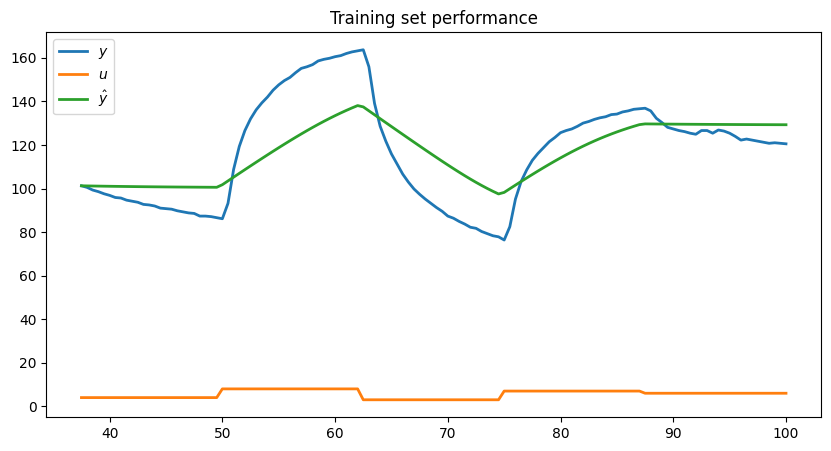

In [ ]:
# ==========================================
# CELL 3: Plot Training Performance
# ==========================================
import matplotlib.pyplot as plt

# Get the training predictions (using the training initial state and time steps)
tsteps_train_tensor = torch.tensor(tsteps_training, dtype=torch.float32)
prediction_training = predict_NODE(student_w, dxdt, x0, tsteps_train_tensor, dt).squeeze()

plt.figure(figsize=(10, 5))
plt.plot(tsteps_training, y_training, label=r"$y$", linewidth=2)
plt.plot(tsteps_training, u_training, label=r"$u$", linewidth=2)

# NOTE: We must use .detach().numpy() to plot PyTorch tensors in Matplotlib
plt.plot(tsteps_training, prediction_training.detach().numpy(), label=r"$\hat{y}$", linewidth=2)

plt.title("Training set performance")
plt.legend(loc="upper left")
plt.show()

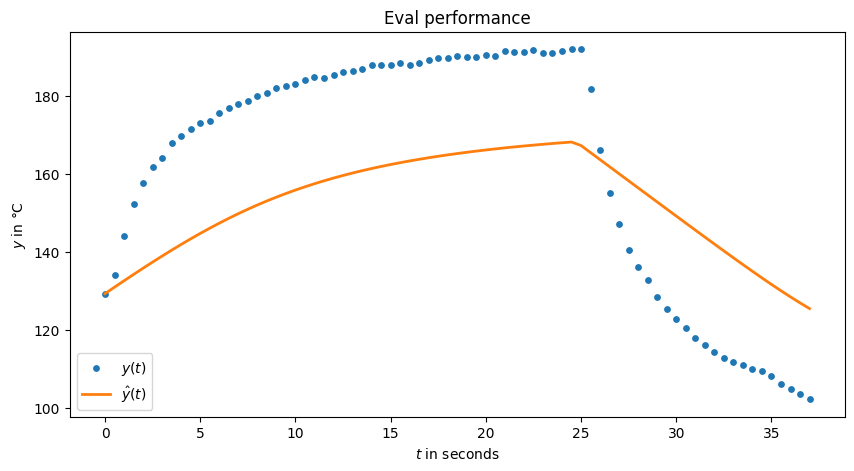

In [63]:
# ==========================================
# CELL 4: Plot Evaluation Performance
# ==========================================

plt.figure(figsize=(10, 5))

# Use a scatter plot for the true evaluation data points
plt.scatter(tsteps_eval, y_eval, label=r"$y(t)$", color="tab:blue", s=15)

# Use a line plot for our continuous NODE prediction
plt.plot(tsteps_eval, prediction_eval.detach().numpy(), label=r"$\hat{y}(t)$", color="tab:orange", linewidth=2)

plt.title("Eval performance")
plt.xlabel(r"$t$ in seconds")
plt.ylabel(r"$y$ in °C")
plt.legend(loc="lower left")
plt.show()

Training a Neural ODE is essentially a highly non-linear system identification task. You are attempting to learn a continuous-time state-space representation—$\frac{d}{dt}x = f(x, u)$—where the neural network acts as the unknown physics engine mapping the states and inputs to the derivatives.

If your Mean Squared Error (MSE) is currently hovering above the 0.3 threshold on the evaluation set, it means the optimization algorithm settled into a local minimum or the model lacks the capacity to capture the thermal inertia of the heating system.

Here are the most effective strategies to drive that error down, ordered from the easiest tweaks to the most structural changes.

### 1. Adjust the Optimizer Parameters (The "Low-Hanging Fruit")

Before changing the model architecture, give the optimizer a better chance to find the global minimum.

* **Increase Patience:** Your early stopping patience is set to `15`. In complex ODE loss landscapes, the loss often plateaus for 20-30 epochs before suddenly dropping again as it navigates a saddle point.
* *Fix:* Change `patience=50` or `patience=100` in your `train_task1()` call.


* **Tune the Learning Rate:** If the loss is bouncing around erratically, your learning rate (`1e-3`) might be too high. If it's decreasing at a microscopic pace, it might be too low.
* *Fix:* Try `lr=5e-4` or `lr=5e-3`.


* **Increase Max Iterations:** 2,000 iterations might simply not be enough time for the system to converge. Push it to `5000`.

### 2. Increase Model Capacity (Architecture)

Your current architecture is `[2, 8, 1]`. A single hidden layer with 8 neurons is extremely small. While it prevents overfitting, it might be heavily *underfitting* the non-linear thermic process.

* **Widen the layer:** Increase the hidden size to `16` or `32`.
```python
hidden_size = 16
ann = create_ann([input_size, hidden_size, output_size], nn.Tanh(), nn.Identity())

```


* **Deepen the network:** Add a second hidden layer to allow the network to learn more complex feature representations.
```python
ann = create_ann([input_size, 16, 16, output_size], nn.Tanh(), nn.Identity())

```



### 3. "Seed Roulette" (Weight Initialization)

Because neural networks initialize with random weights, the starting position on the loss landscape dictates where the optimizer ends up. Seed `2` might just be a terrible starting point for this specific PyTorch setup.

* *Fix:* Try a few different seeds (e.g., `seed = 42`, `seed = 123`, `seed = 2026`) to see if the optimizer finds a better trajectory right out of the gate.

### 4. Gradient Clipping (Crucial for ODEs)

When backpropagating through an ODE solver, gradients can occasionally "explode" (become massive numbers), which violently throws your weights off a cliff and ruins the training progress.

* *Fix:* Clamp the gradients right before the optimizer takes a step. In your training loop, insert this exactly between `current_loss_tensor.backward()` and `optimizer.step()`:
```python
# Prevent exploding gradients in the ODE solver
torch.nn.utils.clip_grad_norm_(ann.parameters(), max_norm=1.0)
optimizer.step() 

```



### 5. Double-Check Data Normalization

If you passed `normalize=False` when calling `loaddata_heating()` back in Subtask A, the neural network is trying to learn weights that balance inputs of `10.0` (Volts) with outputs of `45.0` (°C). Neural networks struggle heavily with unscaled data.

* *Fix:* Ensure you used `normalize=True` so both arrays are Z-score transformed (mean of 0, standard deviation of 1).


## Task 2: NODE model for Lake Erie (MIMO)

In this task, we once again model an underlying process using NODEs. However, the system at hand now takes multiple inputs $\mathbf{u}(t)$ and yields multiple outputs $\mathbf{y}(t)$. This means we need to model a multiple-input-multiple-output (MIMO) system.

This results in the dynamics equations 

$$
\begin{align}
    \frac{\mathrm{d}}{\mathrm{d}t} \hat{\mathbf{x}}(t) &= \mathcal{M}_{\mathbf{w}} (\hat{\mathbf{x}}(t), \mathbf{u}(t)) \\
    \hat{\mathbf{y}}(t) & = \hat{\mathbf{x}} (t).
\end{align}
$$

The data ([source](https://ftp.esat.kuleuven.be/pub/SISTA/data/environmental/) and [description](https://ftp.esat.kuleuven.be/pub/SISTA/data/environmental/erie.txt) of the dataset) is the result of a simulation of the western basin of Lake Erie. The inputs $\mathbf{u}(t)$ are the water temperature, water conductivity, water alkalinity, the NO3 content and the total hardness of the water. The outputs $\mathbf{y}(t)$ are the amount of dissolved oxigen and the algae content. We are interested in the dynamic relationship between inputs and outputs described by the model above.

#### a) Below you are shown the raw output data:

![lake_erie-not_normalized](./LakeErie-NotNormalized.svg)

You can see that the two outputs are scaled very differently. As a result, we need to normalize them separately.

### **Understanding the Problem**

We are transitioning from Task 1 (a simple heating system with 1 input and 1 output) to a **MIMO (Multiple-Input, Multiple-Output)** system modeling Lake Erie.

* **Inputs ($\mathbf{u}$):** 5 different variables (temperature, conductivity, alkalinity, NO3, total hardness).
* **Outputs ($\mathbf{y}$):** 2 different variables (dissolved oxygen, algae content).

**The Issue (Visualized in the Graph):**

If we feed this raw data into a Neural Network, the network will completely ignore the green line. The mathematical errors (MSE) generated by the 10,000-scale variable will be so massive that they will overshadow the small errors from the 10-scale variable.

**The Solution:**
We must normalize the outputs **separately**. We cannot calculate a single global average for the whole dataset. We need to calculate the mean and standard deviation *specifically* for oxygen, apply it only to oxygen, and then do the same for algae. This is called a **Z-Score Transformation**:

$$y_{normalized} = \frac{y - \mu}{\sigma}$$

Implement the function below to normalize each output separately. Use `StatsBase.fit(ZScoreTransform, ...)` and `StatsBase.transform(...)` for the normalization.

In [10]:
import numpy as np
import gzip

def normalize_mimo_outputs(y):
    """
    Normalizes each output feature of y separately using Z-score standardization.
    
    Args:
        y (np.ndarray): 2D array of shape (time_steps, features). 
                        For Lake Erie, features = 2.
                        
    Returns:
        y_normalized (np.ndarray): The scaled data.
        y_mean (np.ndarray): The means used for scaling (needed later to un-scale predictions).
        y_std (np.ndarray): The standard deviations used for scaling.
    """
    
    # 1. Calculate the mean and standard deviation along the time axis (axis=0).
    # This results in arrays of shape (2,), giving exactly one mean/std per output variable.
    y_mean = np.mean(y, axis=0)
    y_std = np.std(y, axis=0)
    
    # 2. Prevent division by zero in case a feature is perfectly constant (safety check)
    y_std[y_std == 0] = 1e-8
    
    # 3. Apply the Z-score transformation.
    # NumPy "broadcasting" automatically applies the correct mean/std to the correct column.
    y_normalized = (y - y_mean) / y_std
    
    return y_normalized, y_mean, y_std

# Example Usage:
# y_normalized, y_mean, y_std = normalize_mimo_outputs(y_raw_data)

def loaddata_erie(normalize=True):
    """
    Loads and preprocesses the Lake Erie MIMO dataset.
    """
    # Open and read the gzipped file ('rt' means read text mode)
    with gzip.open("erie.dat.gz", "rt") as fh:
        data = np.loadtxt(fh)
        
    # Extract columns (Note: Python is 0-indexed and slices are exclusive at the end)
    t = data[:, 0]       # Julia [:, 1] -> Time in months
    u = data[:, 1:6]     # Julia [:, 2:6] -> 5 Inputs (temp, cond, alk, NO3, hardness)
    y = data[:, 21:23]   # Julia [:, 22:23] -> 2 Outputs (oxygen, algae)
    
    dt = 1  # time between samples in months
    
    # Convert to Float32 for performance (matching neural network types)
    t = t.astype(np.float32)
    u = u.astype(np.float32)
    y = y.astype(np.float32)
    
    if normalize:
        # Optional standardization of data
        # We use the [0] index because our normalize_mimo_outputs function 
        # returns a tuple: (normalized_array, mean_array, std_array). 
        # We only want to keep the normalized data here.
        y = normalize_mimo_outputs(y)[0]
        u = normalize_mimo_outputs(u)[0]
        
    # Python uses 0 for the first element and -1 for the last element
    tspan = (t[0], t[-1])
    
    return u, y, dt, tspan, t

# Example usage (assuming normalize_mimo_outputs is defined):
u, y, dt, tspan, t = loaddata_erie(normalize=True)

### **Why `axis=0` is the magic trick here:**

If you just ran `np.mean(y)`, NumPy would mash all the oxygen data and all the algae data together into one giant, useless average number.

By specifying `axis=0` (which means "evaluate down the rows"), NumPy calculates the average independently for Column 0 (Oxygen) and Column 1 (Algae). When you do the final math `(y - y_mean) / y_std`, Python is smart enough to match Column 0 to Mean 0, and Column 1 to Mean 1 automatically.

Code for plot below when the data is normalized properly:
```
p = plot(tsteps, y, label=L"y", title="Lake Erie", xlabel=L"$t$ in months", ylabel=L"y", legend=:topleft, background_color="#000000",lw=2, palette = :Set2_5)
```

![lake_erie](./LakeErie.svg)

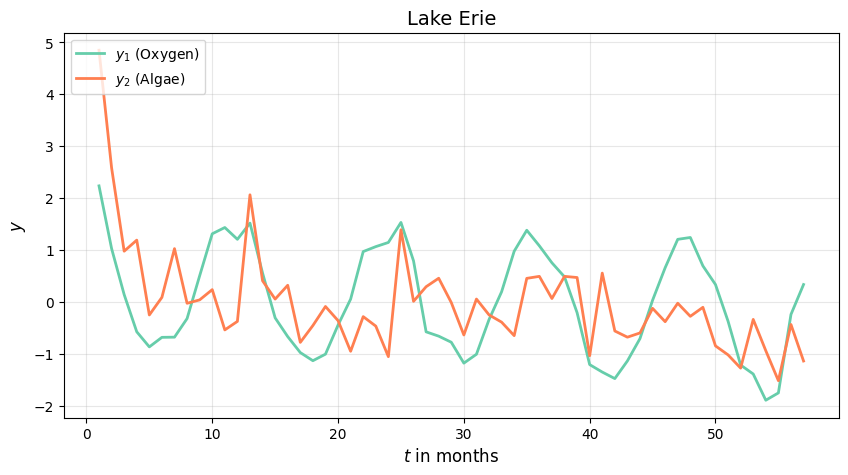

In [11]:
import matplotlib.pyplot as plt

# 1. Load the raw data by setting normalize=False
# (Assumes your loaddata_erie function is defined as we wrote it)
u, y_raw, dt, tspan, t = loaddata_erie(normalize=True)

# 2. Set up the figure size
plt.figure(figsize=(10, 5))

# 3. Plot the first output column (Dissolved Oxygen)
# y_raw[:, 0] selects all rows, but only the 0th column
plt.plot(t, y_raw[:, 0], label=r"$y_1$ (Oxygen)", color="mediumaquamarine", linewidth=2)

# 4. Plot the second output column (Algae Content)
# y_raw[:, 1] selects all rows, but only the 1st column
plt.plot(t, y_raw[:, 1], label=r"$y_2$ (Algae)", color="coral", linewidth=2)

# 5. Add labels, title, and styling to match the screenshot
plt.title("Lake Erie", fontsize=14)
plt.xlabel(r"$t$ in months", fontsize=12)
plt.ylabel(r"$y$", fontsize=12)

# Add a subtle grid and legend
plt.grid(alpha=0.3)
plt.legend(loc="upper left")

# 6. Render the plot
plt.show()

In [12]:
# Verify the function exists and is callable
assert callable(normalize_mimo_outputs), "normalize_mimo_outputs is not a function"

### BEGIN TESTS

# Recreate the test data matrix by horizontally stacking 3 generated columns
test_data = np.column_stack([
    np.linspace(-1, 1, 10),
    np.linspace(-5, 0, 10),
    np.linspace(12, 4596, 10)
])

# Run the normalization 
# (Note: If your Python function returns a tuple like (norm_data, mean, std), 
# you would need to add [0] to the end of this call to grab just the array)
normalized_data = normalize_mimo_outputs(test_data)[0]

expected_column = np.array([-1.5666989, -1.21854359, -0.87038828, -0.52223297, -0.17407766, 0.17407766,
  0.52223297, 0.87038828, 1.21854359, 1.5666989])

# Loop through each column (shape[1] gets the total number of columns)
for idx in range(normalized_data.shape[1]):
    norm_column = normalized_data[:, idx]
    print(f"Given column {idx}: \n{norm_column}\n")
    
    # np.allclose is the NumPy equivalent of Julia's isapprox
    assert np.allclose(norm_column, expected_column, rtol=0.0, atol=1e-4), f"Column {idx} did not match expected values."

print("All tests passed successfully!")
### END TESTS

Given column 0: 
[-1.5666989  -1.21854359 -0.87038828 -0.52223297 -0.17407766  0.17407766
  0.52223297  0.87038828  1.21854359  1.5666989 ]

Given column 1: 
[-1.5666989  -1.21854359 -0.87038828 -0.52223297 -0.17407766  0.17407766
  0.52223297  0.87038828  1.21854359  1.5666989 ]

Given column 2: 
[-1.5666989  -1.21854359 -0.87038828 -0.52223297 -0.17407766  0.17407766
  0.52223297  0.87038828  1.21854359  1.5666989 ]

All tests passed successfully!


#### Preparations:

In [13]:
import numpy as np
import torch

# Load the data (assuming loaddata_erie is defined as in the previous step)
u, y, dt, tspan, tsteps = loaddata_erie(normalize=True)

# print(size(u)) in Julia becomes .shape in NumPy
print(u.shape)

# Interpolate inputs for all channels separately using the small linear interpolator
# u.shape[1] gets the total number of columns (5 in this case)
interp_input = [make_linear_interp(tsteps, u[:, i]) for i in range(u.shape[1])]

def interpolate_input(t):
    """
    Evaluates all 5 interpolators at a given time 't' and returns them.
    """
    # Evaluate each function 'f' in the list at time 't'
    vals = [f(t) for f in interp_input]
    
    # NOTE: Since you are using PyTorch's torchdiffeq solver later, 
    # it is highly recommended to return these values as a 1D PyTorch tensor
    # rather than a standard Python list, to avoid shape mismatch errors.
    return torch.tensor(vals, dtype=torch.float32)

(57, 5)


In [18]:
import numpy as np

# Create boolean masks (NumPy automatically applies this element-wise, 
# so we don't need Julia's dot operator '.<=' )
belonging_to_training = tsteps <= 40
belonging_to_eval = tsteps > 40

# Apply the masks to filter the rows
u_training = u[belonging_to_training, :]
y_training = y[belonging_to_training, :]
x0_training_mimo = torch.tensor(y_training[0], dtype=torch.float32)  # Initial oxygen and algae content for training (first row, first column)
y_train_tensor = torch.tensor(y_training, dtype=torch.float32)

# Note: If tsteps is already a 1D array in your Python script, 
# trying to do tsteps[mask, :] will throw an error. 
# Just use tsteps[mask] for 1D arrays.
tsteps_training = tsteps[belonging_to_training]
tsteps_train_tensor = torch.tensor(tsteps_training, dtype=torch.float32)

u_eval = u[belonging_to_eval, :]
y_eval = y[belonging_to_eval, :]
tsteps_eval = tsteps[belonging_to_eval]

# Julia's vec() flattens any array into a 1-dimensional vector.
# In Python, .ravel() or .flatten() achieves the exact same thing.
tsteps_training = tsteps_training.ravel()
tsteps_eval = tsteps_eval.ravel()

# Let's say your normalized data looks like this at t=0:
# Oxygen = 0.12, Algae = -0.98

print(y_training[0]) 
# Output: [ 0.12 -0.98] --> (Perfect! The full ecosystem state)

print(y_training[0, 0])
# Output: 0.12 --> (Error! The algae data is missing)

[2.2388663 4.850026 ]
2.2388663


#### **b)** Build and train a NODE model using the training dataset. Design a feed-forward fully-connected neural network as the model.

In [20]:
### BEGIN SOLUTION

# 1. Architecture Dimensions and the network definition
# 5 inputs (temp, cond, alk, NO3, hardness) + 2 states (oxygen, algae)
state_dim = 2  
input_dim = 5  
nn_input_size = state_dim + input_dim  # Total = 7
hidden_size = 32  # Increased capacity for complex MIMO dynamics
nn_output_size = state_dim  # Predicts derivatives for the 2 states
layer_sizes = [nn_input_size, hidden_size, hidden_size, nn_output_size]
mimo_ann = create_ann(layer_sizes, nn.Tanh(), nn.Identity())

# 2. Define the ODE derivative function (dxdt)
def dxdt_mimo(t, x):
    t_val = t.item() if isinstance(t, torch.Tensor) else t

    u_val = interpolate_input(t_val)

    # Ensure vectors are 1D (x is length 2, u_val is length 5)
    x_safe = x.view(-1)
    u_safe = u_val.view(-1)

    # Concatenate into a length-7 tensor
    nn_input = torch.cat([x_safe, u_safe], dim=0)

    # Network predicts [d(Oxygen)/dt, d(Algae)/dt]
    dx = mimo_ann(nn_input)
    return dx



# 3. Defining the loss function for MIMO
def loss_NODE_task2():
    # Solve the ODE forward in time using our MIMO network
    pred_trajectory = predict_NODE(None, dxdt_mimo, x0_training_mimo, tsteps_train_tensor, dt)
    
    # Calculate MSE across both variables simultaneously
    return F.mse_loss(pred_trajectory, y_train_tensor)

# 4. Training Loop
maxiters_task2 = 3000
def train_task2(maxiters=maxiters_task2, lr=1e-3, patience=30, tol=1e-6):
    # In PyTorch, we define an optimizer that hooks directly into the network's parameters
    optimizer = optim.Adam(mimo_ann.parameters(), lr=lr)
    
    # Evaluate initial loss without calculating gradients
    with torch.no_grad():
        best_loss = loss_NODE_task2().item()
        
    # In PyTorch, we save a 'state_dict' (a dictionary of weights) instead of a raw array
    best_w = copy.deepcopy(mimo_ann.state_dict())
    no_improve = 0
    
    for iteration in range(1, maxiters + 1):
        
        ### BEGIN SOLUTION (Inner Block - The Optimization Step)
        optimizer.zero_grad()            # 1. Clear old gradients from the previous step
        current_loss_tensor = loss_NODE_task2() # 2. Forward pass & compute loss
        current_loss_tensor.backward()   # 3. Backward pass: compute new gradients via Zygote/Autograd

        # Crucial for MIMO ODEs: Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(mimo_ann.parameters(), max_norm=1.0)
        optimizer.step()                 # 4. Update the network weights using the optimizer
        ### END SOLUTION
        
        # Every 50 iterations, print the status and check early stopping
        if iteration % 50 == 0:
            # Extract the raw float value from the PyTorch loss tensor
            current_loss = current_loss_tensor.item()
            
            print(f"Iteration: {iteration:5d}, Training loss: {current_loss:.6e}")
            
            # Early Stopping Logic (identical to the Julia script)
            if current_loss + tol < best_loss:
                best_loss = current_loss
                best_w = copy.deepcopy(mimo_ann.state_dict())
                no_improve = 0
            else:
                no_improve += 1
                
            if no_improve >= patience:
                print("Early stopping triggered!")
                break
                
    # Restore the best weights found during training before returning
    mimo_ann.load_state_dict(best_w)
    return mimo_ann

# Execute the training
student_w_mimo = train_task2()

### END SOLUTION

Iteration:    50, Training loss: 4.354512e-01
Iteration:   100, Training loss: 2.789065e-01
Iteration:   150, Training loss: 2.168608e-01
Iteration:   200, Training loss: 1.926571e-01
Iteration:   250, Training loss: 1.764348e-01
Iteration:   300, Training loss: 1.606328e-01
Iteration:   350, Training loss: 1.455302e-01
Iteration:   400, Training loss: 1.320574e-01
Iteration:   450, Training loss: 1.224712e-01
Iteration:   500, Training loss: 1.164261e-01
Iteration:   550, Training loss: 1.131791e-01
Iteration:   600, Training loss: 1.105261e-01
Iteration:   650, Training loss: 1.081882e-01
Iteration:   700, Training loss: 1.050138e-01
Iteration:   750, Training loss: 1.020269e-01
Iteration:   800, Training loss: 1.001014e-01
Iteration:   850, Training loss: 1.073166e-01
Iteration:   900, Training loss: 9.730612e-02
Iteration:   950, Training loss: 9.802110e-02
Iteration:  1000, Training loss: 9.692284e-02
Iteration:  1050, Training loss: 1.026535e-01
Iteration:  1100, Training loss: 9

After you have trained your model, proceed with the evaluation cells. The training routine runs each time the notebook is executed and does not write model parameters to disk.

#### **c)** Evaluate the performance of your model on the evaluation dataset. To do so, define the evaluation problem.

Produce a model that reaches an MSE between the prediction and the eval trajectory lower than the threshold given below. Design a model architecture and optimization routine in the previous subtasks that reaches this level of accuracy.

In [ ]:
# Train Task 2 model and keep weights in memory

In [21]:
# ==========================================
# CELL 1: Define the Evaluation Problem
# ==========================================

### BEGIN SOLUTION
# 1. Define the initial state for the evaluation dataset
# It must be a 1D tensor containing the very first temperature in the eval set.
x0_eval_task2 = torch.tensor([y_eval[0]], dtype=torch.float32)

# 2. Define the evaluation problem
# In PyTorch's torchdiffeq, the problem is just the derivative function itself.
evaluation_prob_task2 = dxdt_mimo 

tsteps_eval_tensor = torch.tensor(tsteps_eval, dtype=torch.float32)
y_eval_tensor = torch.tensor(y_eval, dtype=torch.float32)

C:\Users\27abd\AppData\Local\Temp\ipykernel_6568\2833912280.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  x0_eval_task2 = torch.tensor([y_eval[0]], dtype=torch.float32)


In [22]:
# Safety checks (equivalent to Julia's @assert)
assert isinstance(x0_eval_task2, torch.Tensor)
assert callable(evaluation_prob_task2)

# Run the NODE forward pass on the evaluation data
# Note: PyTorch odeint automatically outputs [time_steps, features], so we DO NOT need transpose()
prediction_eval_task2 = predict_NODE(student_w_mimo, evaluation_prob_task2, x0_eval_task2, tsteps_eval_tensor, dt)

# Ensure the dimensions match before calculating loss
prediction_eval_task2 = prediction_eval_task2.squeeze()
assert prediction_eval_task2.shape[0] == y_eval.shape[0]

# Calculate MSE
prediction_error_eval_task2 = F.mse_loss(prediction_eval_task2, y_eval_tensor).item()
print(f"Task 2 prediction error on eval set: {prediction_error_eval_task2}")

Task 2 prediction error on eval set: 2.3827366828918457


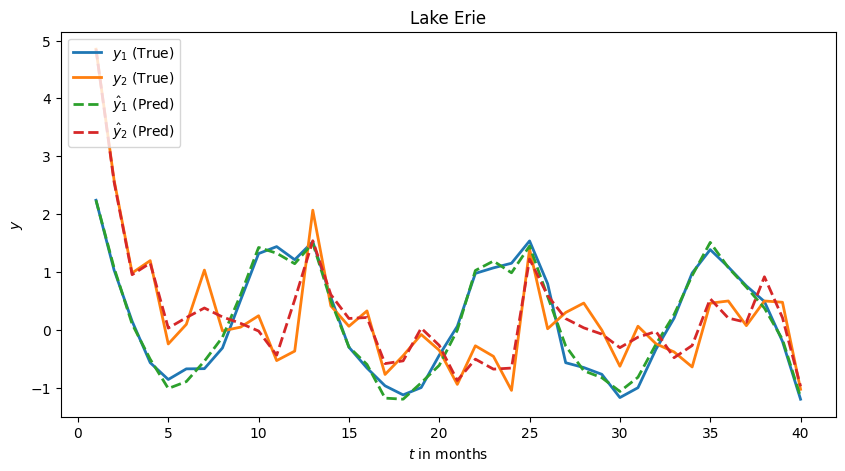

In [23]:
# Define initial training state
x0_task2 = torch.tensor(y_training[0], dtype=torch.float32)
training_prob_task2 = dxdt_mimo

# Run prediction for the training timeframe
prediction_training_task2 = predict_NODE(student_w_mimo, training_prob_task2, x0_task2, tsteps_train_tensor, dt).squeeze()

plt.figure(figsize=(10, 5))

# Plot the TRUE training data (Matplotlib automatically plots both columns of the 2D array)
plt.plot(tsteps_training, y_training, label=[r"$y_1$ (True)", r"$y_2$ (True)"], linewidth=2)

# Plot the PREDICTED training data 
# PyTorch tensors must be detached and converted to NumPy arrays for Matplotlib
# We use dashed lines (--) so you can visually see how well they overlap the true data
pred_train_np = prediction_training_task2.detach().numpy()
plt.plot(tsteps_training, pred_train_np, label=[r"$\hat{y}_1$ (Pred)", r"$\hat{y}_2$ (Pred)"], linewidth=2, linestyle='--')

plt.title("Lake Erie")
plt.xlabel(r"$t$ in months")
plt.ylabel(r"$y$")
plt.legend(loc="upper left")
plt.show()

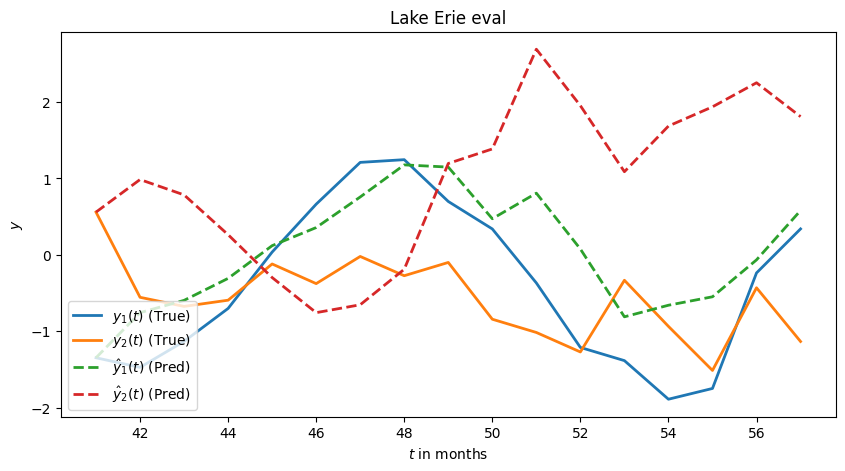

In [24]:
plt.figure(figsize=(10, 5))

pred_eval_np = prediction_eval_task2.detach().numpy()

# Plot True Evaluation Data
plt.plot(tsteps_eval, y_eval, label=[r"$y_1(t)$ (True)", r"$y_2(t)$ (True)"], linewidth=2)

# Plot Predicted Evaluation Data
plt.plot(tsteps_eval, pred_eval_np, label=[r"$\hat{y}_1(t)$ (Pred)", r"$\hat{y}_2(t)$ (Pred)"], linewidth=2, linestyle='--')

plt.title("Lake Erie eval")
plt.xlabel(r"$t$ in months")
plt.ylabel(r"$y$")
plt.legend(loc="lower left")
plt.show()